In [9]:
%matplotlib widget

In [10]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
from astropy.modeling import models
import astropy.units as u

In [11]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/MCG+01-32-049_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/MGC+01-32-049/MCG+01-32-049_1/MCG+01-32-049_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     377   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        58   (2094, 964)   float32   


In [12]:
image_cut = image[52:172, 0:1890]
image_error_cut = image_error[52:172, 0:1890]

In [13]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Text(0.5, 45.40277777777776, 'wavelenght')

In [14]:
z = 0.00309
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

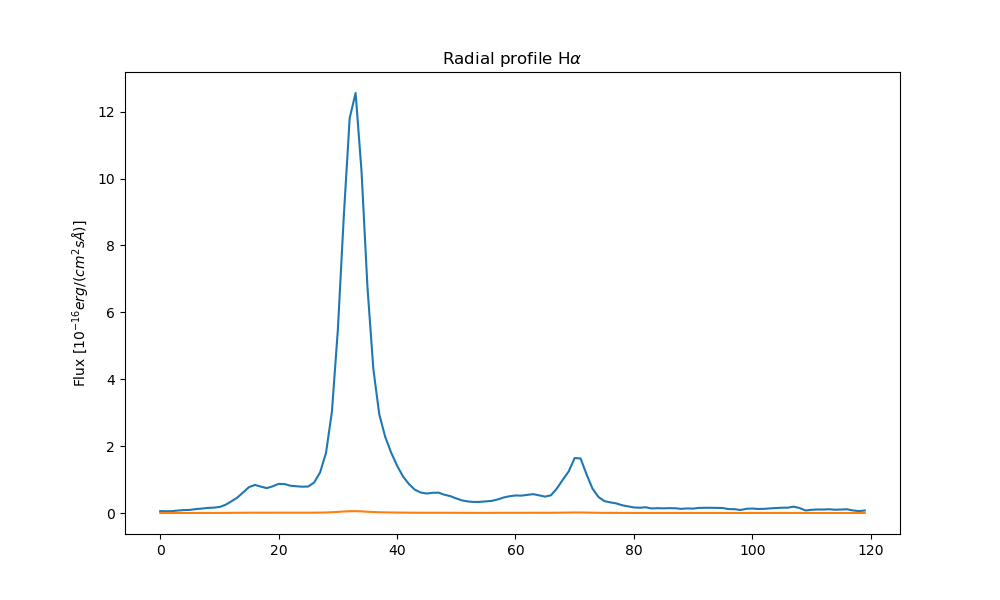

In [15]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

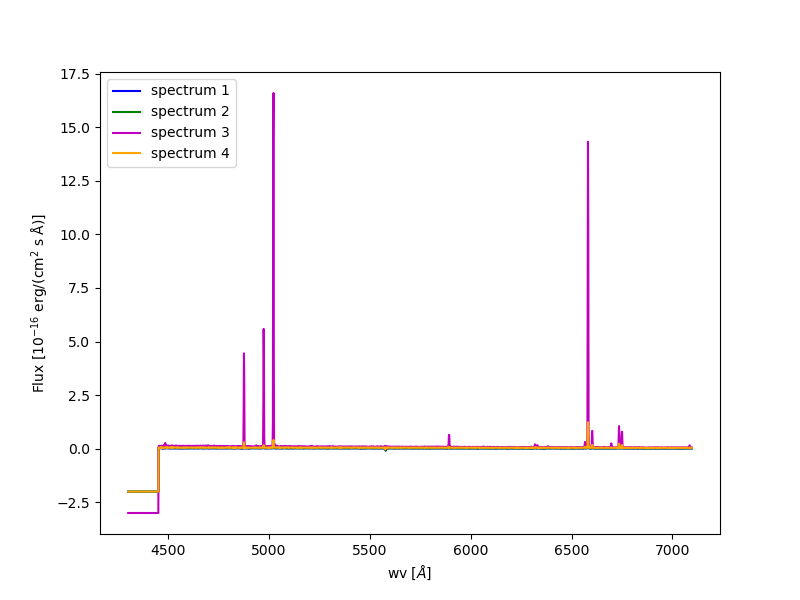

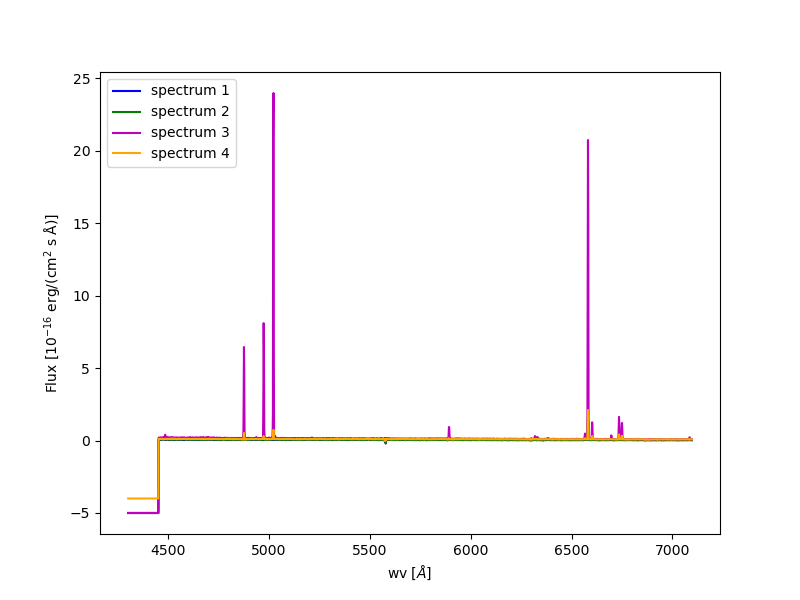

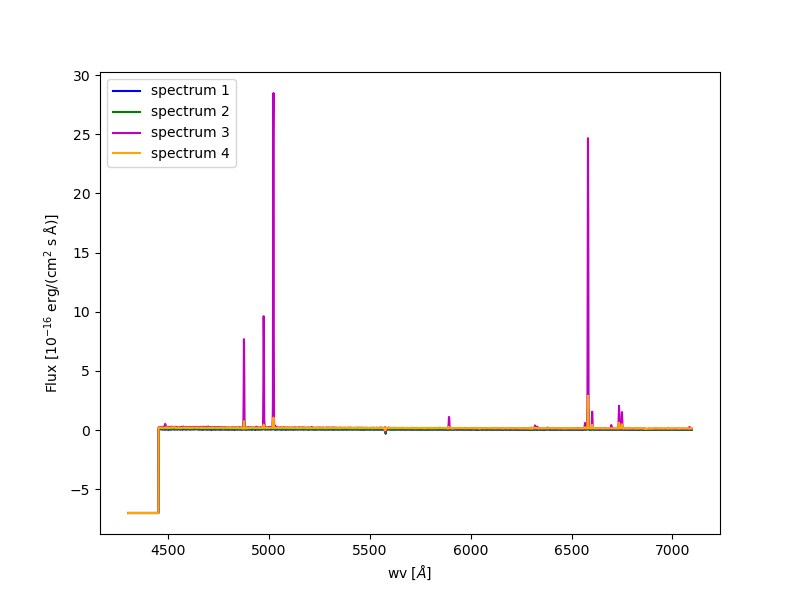

In [16]:
#fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_789/Fit/Halpha_fit.csv", index_col=0)
os.makedirs('1Sigma', exist_ok=True)
os.makedirs('2Sigma', exist_ok=True)
os.makedirs('3Sigma', exist_ok=True)

seeing = 2.778 #in pixels
sigma = seeing/2.35
peaks = [15.7, 20.2, 33, 70.4]       #fit_HA.iloc[3].values

plt.figure(figsize=(8,6))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_1 = np.zeros((len(peaks), image_error_cut.shape[1]))
data1 = []
colors = ['blue', 'green','m', 'orange', 'purple', 'darkblue']
#Cut one sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-sigma)*(x_axes < peaks[i]+sigma)
    spectra_1[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_1[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_1[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1), spectra_err_1[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('1Sigma', f'Spectrum_1s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)

plt.figure(figsize=(8,6))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_2 = np.zeros((len(peaks), image_error_cut.shape[1]))
data2 = []

#Cut two sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-2*sigma)*(x_axes < peaks[i]+2*sigma)
    spectra_2[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_2[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_2[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1), spectra_err_2[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('2Sigma', f'Spectrum_2s_{i+1}.txt')  
    np.savetxt(filename, spectrum_table)
    
plt.figure(figsize=(8,6))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_3 = np.zeros((len(peaks), image_error_cut.shape[1]))
data3 = []
#Cut three sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-3*sigma)*(x_axes < peaks[i]+3*sigma)
    spectra_3[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_3[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_3[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1), spectra_err_3[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('3Sigma', f'Spectrum_3s_{i+1}.txt') 
    np.savetxt(filename, spectrum_table)

## S/N continuum

In [17]:
import pandas as pd

mask_continuum_1 = (wv > 4550)*(wv < 4850)
mask_continuum_2 = (wv > 5100)*(wv < 5500)
mask_continuum_3 = (wv > 6350)*(wv < 6550)

# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_1[i, mask_continuum_1])
    noise_1 = np.std(spectra_1[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_1[i, mask_continuum_2])
    noise_2 = np.std(spectra_1[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_1[i, mask_continuum_3])
    noise_3 = np.std(spectra_1[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('1Sigma', 'SNR_1s_continuum.csv')
df_path_signal = os.path.join('1Sigma', 'Signal_1s_continuum.csv')
df_path_noise = os.path.join('1Sigma', 'Noise_1s_continuum.csv')
df_path_combined = os.path.join('1Sigma', 'Combined_1s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('1Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    3.230063    5.019437   11.036204    8.745574
Continuum_2    4.669020    6.279658   12.621806   10.338451
Continuum_3    3.760960    4.578786    9.220054   11.663048

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.017237    0.030092    0.121594    0.051059
Continuum_2    0.016326    0.024258    0.099064    0.050510
Continuum_3    0.012743    0.017468    0.070475    0.044548

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.005337    0.005995    0.011018    0.005838
Continuum_2    0.003497    0.003863    0.007849    0.004886
Continuum_3    0.003388    0.003815    0.007644    0.003820

DataFrame Combinato:
                   SNR                                      Signal             \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_4 Spectrum_1 Spectrum_2   
Continuum_1   3.230063   5.019437  11.036204

In [18]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_2[i, mask_continuum_1])
    noise_1 = np.std(spectra_2[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_2[i, mask_continuum_2])
    noise_2 = np.std(spectra_2[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_2[i, mask_continuum_3])
    noise_3 = np.std(spectra_2[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('2Sigma', 'SNR_2s_continuum.csv')
df_path_signal = os.path.join('2Sigma', 'Signal_2s_continuum.csv')
df_path_noise = os.path.join('2Sigma', 'Noise_2s_continuum.csv')
df_path_combined = os.path.join('2Sigma', 'Combined_2s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('2Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    4.922467    6.182360   11.977541   11.811696
Continuum_2    6.902691    8.512085   13.613107   12.968780
Continuum_3    4.737943    5.872778    9.928338   13.977219

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.046878    0.072516    0.188486    0.105683
Continuum_2    0.042141    0.058362    0.153742    0.102047
Continuum_3    0.031616    0.042255    0.108397    0.089296

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.009523    0.011729    0.015737    0.008947
Continuum_2    0.006105    0.006856    0.011294    0.007869
Continuum_3    0.006673    0.007195    0.010918    0.006389

DataFrame Combinato:
                   SNR                                      Signal             \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_4 Spectrum_1 Spectrum_2   
Continuum_1   4.922467   6.182360  11.977541

In [19]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []

# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_3[i, mask_continuum_1])
    noise_1 = np.std(spectra_3[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_3[i, mask_continuum_2])
    noise_2 = np.std(spectra_3[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_3[i, mask_continuum_3])
    noise_3 = np.std(spectra_3[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)

# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]

# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)

print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)

# Salvataggio dei file
df_path_snr = os.path.join('3Sigma', 'SNR_3s_continuum.csv')
df_path_signal = os.path.join('3Sigma', 'Signal_3s_continuum.csv')
df_path_noise = os.path.join('3Sigma', 'Noise_3s_continuum.csv')
df_path_combined = os.path.join('3Sigma', 'Combined_3s_continuum.csv')

# Assicurati che la directory esista
os.makedirs('3Sigma', exist_ok=True)

df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')

print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    5.576971    7.034153   12.198102   14.089232
Continuum_2    7.670658    9.644778   14.054444   15.686759
Continuum_3    5.059868    6.727184   10.527284   17.425449

DataFrame Signal:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.065178    0.101592    0.246555    0.199522
Continuum_2    0.058214    0.082214    0.200180    0.189287
Continuum_3    0.043551    0.060438    0.140392    0.161420

DataFrame Noise:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4
Continuum_1    0.011687    0.014443    0.020213    0.014161
Continuum_2    0.007589    0.008524    0.014243    0.012067
Continuum_3    0.008607    0.008984    0.013336    0.009263

DataFrame Combinato:
                   SNR                                      Signal             \
            Spectrum_1 Spectrum_2 Spectrum_3 Spectrum_4 Spectrum_1 Spectrum_2   
Continuum_1   5.576971   7.034153  12.198102

## S/N emission lines 

In [20]:
def SNR_line(wv, wv_line, spectra, peaks):
    left_region = (wv > wv_line-25)*(wv < wv_line-10) 
    right_region = (wv > wv_line+10)*(wv < wv_line+25) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise 

def SNR_SII_line(wv, wv_line, spectra, peaks):
    left_region = (wv > 6730-15)*(wv < 6730) 
    right_region = (wv > 6756)*(wv < 6756+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, wv_line, spectra, peaks):
    left_region = (wv > 6560-15) & (wv < 6560)
    right_region = (wv > 6610) & (wv < 6610+15)
    clean_mask = left_region | right_region #But also for the two NII lines bc they are closed

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))

    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 

In [21]:
index = ['Component_1', 'Component_2', 'Component_3', 'Component_4']
SNR_HB_1, signal_HB_1, noise_HB_1 = SNR_line(wv, l_HB, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_HB_1).reshape(-1, 1),
    np.array(signal_HB_1).reshape(-1, 1),
    np.array(noise_HB_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index )
df_path = os.path.join('1Sigma', 'SNR_HB_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_2, signal_HB_2, noise_HB_2 = SNR_line(wv, l_HB, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_HB_2).reshape(-1, 1),
    np.array(signal_HB_2).reshape(-1, 1),
    np.array(noise_HB_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_HB_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_3, signal_HB_3, noise_HB_3 = SNR_line(wv, l_HB, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_HB_3).reshape(-1, 1),
    np.array(signal_HB_3).reshape(-1, 1),
    np.array(noise_HB_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_HB_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_1, signal_SII_1, noise_SII_1 = SNR_SII_line(wv, l_SII_1, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_SII_1).reshape(-1, 1),
    np.array(signal_SII_1).reshape(-1, 1),
    np.array(noise_SII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma','SNR_SII_1_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2, signal_SII_2, noise_SII_2 = SNR_SII_line(wv, l_SII_1, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_SII_2).reshape(-1, 1),
    np.array(signal_SII_2).reshape(-1, 1),
    np.array(noise_SII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma','SNR_SII_1_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_3, signal_SII_3, noise_SII_3 = SNR_SII_line(wv, l_SII_1, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_SII_3).reshape(-1, 1),
    np.array(signal_SII_3).reshape(-1, 1),
    np.array(noise_SII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma','SNR_SII_1_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_1, signal_SII_2_1, noise_SII_2_1 = SNR_SII_line(wv, l_SII_2, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_1).reshape(-1, 1),
    np.array(signal_SII_2_1).reshape(-1, 1),
    np.array(noise_SII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma','SNR_SII_2_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_2, signal_SII_2_2, noise_SII_2_2 = SNR_SII_line(wv, l_SII_2, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_2).reshape(-1, 1),
    np.array(signal_SII_2_2).reshape(-1, 1),
    np.array(noise_SII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma','SNR_SII_2_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_3, signal_SII_2_3, noise_SII_2_3 = SNR_SII_line(wv, l_SII_2, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_3).reshape(-1, 1),
    np.array(signal_SII_2_3).reshape(-1, 1),
    np.array(noise_SII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma','SNR_SII_2_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_1, signal_OIII_1, noise_OIII_1 = SNR_line(wv, l_OIII_1, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_OIII_1).reshape(-1, 1),
    np.array(signal_OIII_1).reshape(-1, 1),
    np.array(noise_OIII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma', 'SNR_OIII_1_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2, signal_OIII_2, noise_OIII_2 = SNR_line(wv, l_OIII_1, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2).reshape(-1, 1),
    np.array(signal_OIII_2).reshape(-1, 1),
    np.array(noise_OIII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_OIII_1_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_3, signal_OIII_3, noise_OIII_3 = SNR_line(wv, l_OIII_1, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_OIII_3).reshape(-1, 1),
    np.array(signal_OIII_3).reshape(-1, 1),
    np.array(noise_OIII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_OIII_1_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_1, signal_OIII_2_1, noise_OIII_2_1 = SNR_line(wv, l_OIII_2, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_1).reshape(-1, 1),
    np.array(signal_OIII_2_1).reshape(-1, 1),
    np.array(noise_OIII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma', 'SNR_OIII_2_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_2, signal_OIII_2_2, noise_OIII_2_2 = SNR_line(wv, l_OIII_2, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_2).reshape(-1, 1),
    np.array(signal_OIII_2_2).reshape(-1, 1),
    np.array(noise_OIII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_OIII_2_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_3, signal_OIII_2_3, noise_OIII_2_3 = SNR_line(wv, l_OIII_2, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_3).reshape(-1, 1),
    np.array(signal_OIII_2_3).reshape(-1, 1),
    np.array(noise_OIII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_OIII_2_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_1, signal_HA_1, noise_HA_1 = SNR_HA_NII(wv, l_HA, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_HA_1).reshape(-1, 1),
    np.array(signal_HA_1).reshape(-1, 1),
    np.array(noise_HA_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma', 'SNR_HA_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_2, signal_HA_2, noise_HA_2 = SNR_HA_NII(wv, l_HA, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_HA_2).reshape(-1, 1),
    np.array(signal_HA_2).reshape(-1, 1),
    np.array(noise_HA_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_HA_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_3, signal_HA_3, noise_HA_3 = SNR_HA_NII(wv, l_HA, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_HA_3).reshape(-1, 1),
    np.array(signal_HA_3).reshape(-1, 1),
    np.array(noise_HA_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_HA_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_1, signal_NII_1, noise_NII_1 = SNR_HA_NII(wv, l_NII_1, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_NII_1).reshape(-1, 1),
    np.array(signal_NII_1).reshape(-1, 1),
    np.array(noise_NII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma', 'SNR_NII_1_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2, signal_NII_2, noise_NII_2 = SNR_HA_NII(wv, l_NII_1, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_NII_2).reshape(-1, 1),
    np.array(signal_NII_2).reshape(-1, 1),
    np.array(noise_NII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_NII_1_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_3, signal_NII_3, noise_NII_3 = SNR_HA_NII(wv, l_NII_1, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_NII_3).reshape(-1, 1),
    np.array(signal_NII_3).reshape(-1, 1),
    np.array(noise_NII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_NII_1_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_1, signal_NII_2_1, noise_NII_2_1 = SNR_HA_NII(wv, l_NII_2, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_1).reshape(-1, 1),
    np.array(signal_NII_2_1).reshape(-1, 1),
    np.array(noise_NII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1Sigma', 'SNR_NII_2_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_2, signal_NII_2_2, noise_NII_2_2 = SNR_HA_NII(wv, l_NII_2, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_2).reshape(-1, 1),
    np.array(signal_NII_2_2).reshape(-1, 1),
    np.array(noise_NII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('2Sigma', 'SNR_NII_2_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_3, signal_NII_2_3, noise_NII_2_3 = SNR_HA_NII(wv, l_NII_2, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_3).reshape(-1, 1),
    np.array(signal_NII_2_3).reshape(-1, 1),
    np.array(noise_NII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('3Sigma', 'SNR_NII_2_3s.csv')
df.to_csv(df_path, float_format='%.3f')

## Redshift

In [22]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Numero di righe trovate (regione centrale, wv > 4451 Å): 9
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
 4874.97999999983   emission               268
4972.659999999802   emission               334
5021.499999999787   emission               367
 6061.93999999948   emission              1070
6581.419999999327   emission              1421
6602.139999999321   emission              1435
6735.339999999282   emission              1525
6750.139999999277   emission              1535
5573.539999999624 absorption               740
Numero di righe trovate (regione centrale, wv > 4451 Å): 9
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
 4874.97999999983   emission               268
4972.659999999802   emission               334
5021.499999999787   emission               367
6581.419999999327   emission        

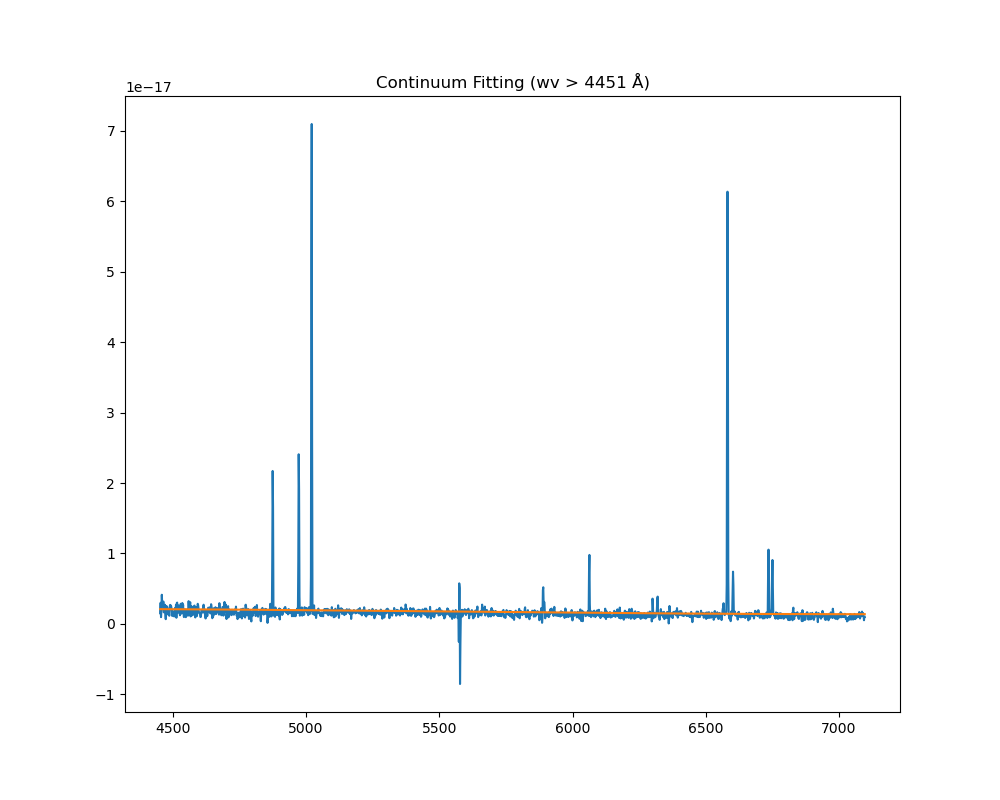

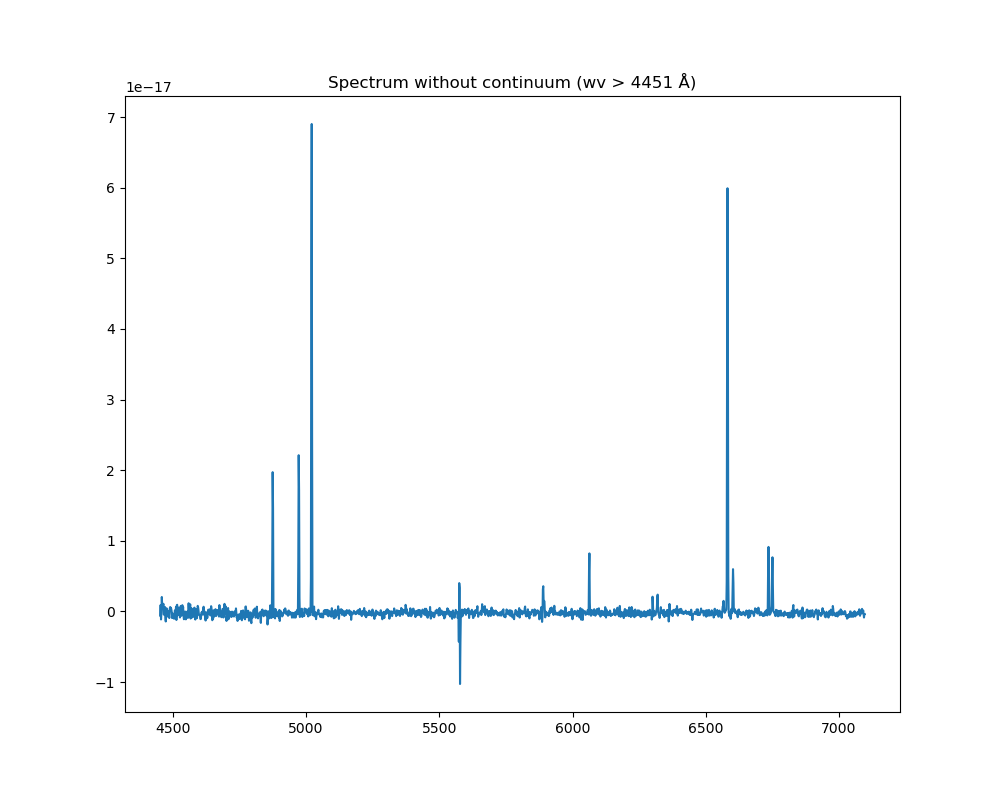

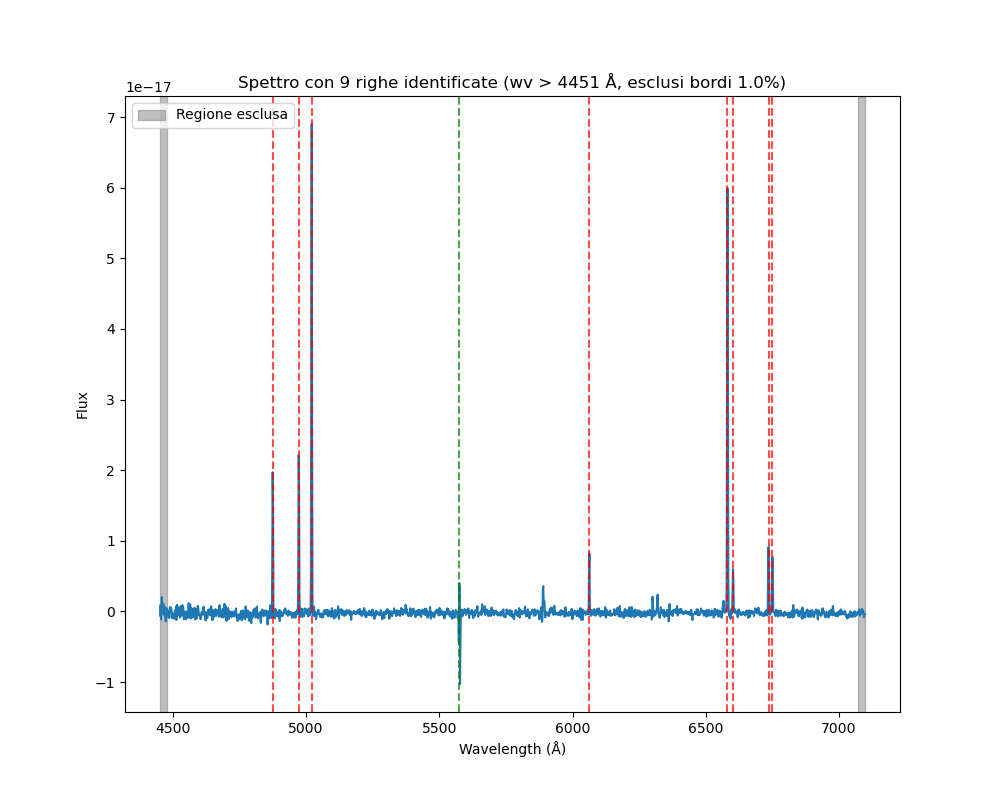

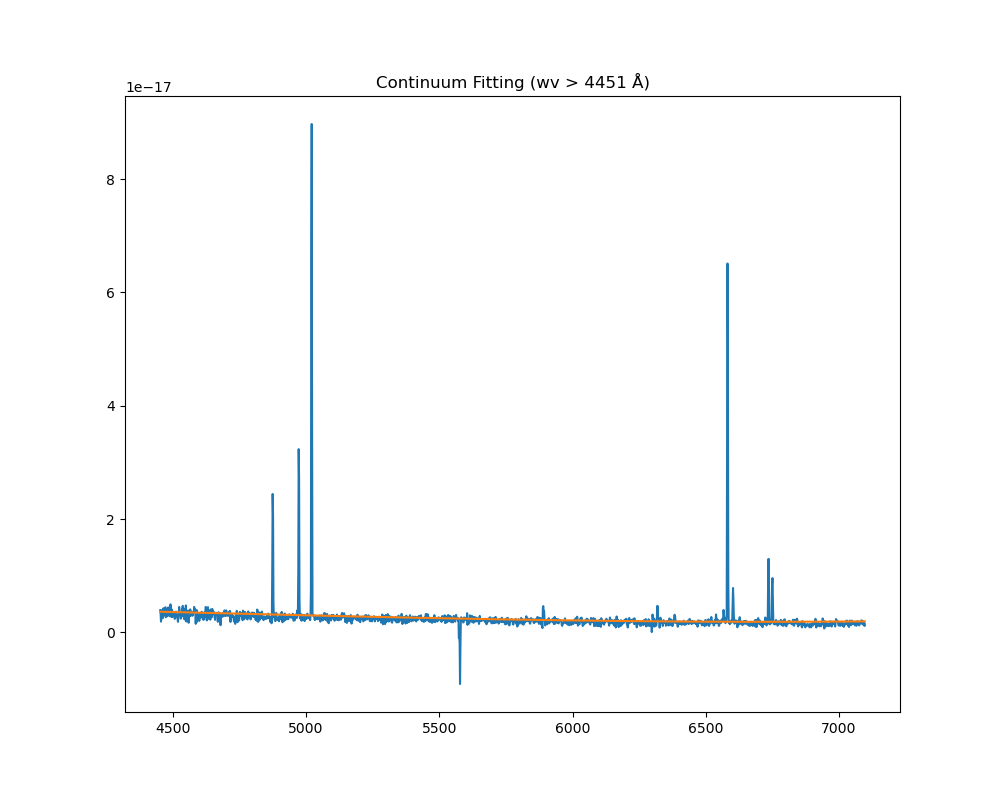

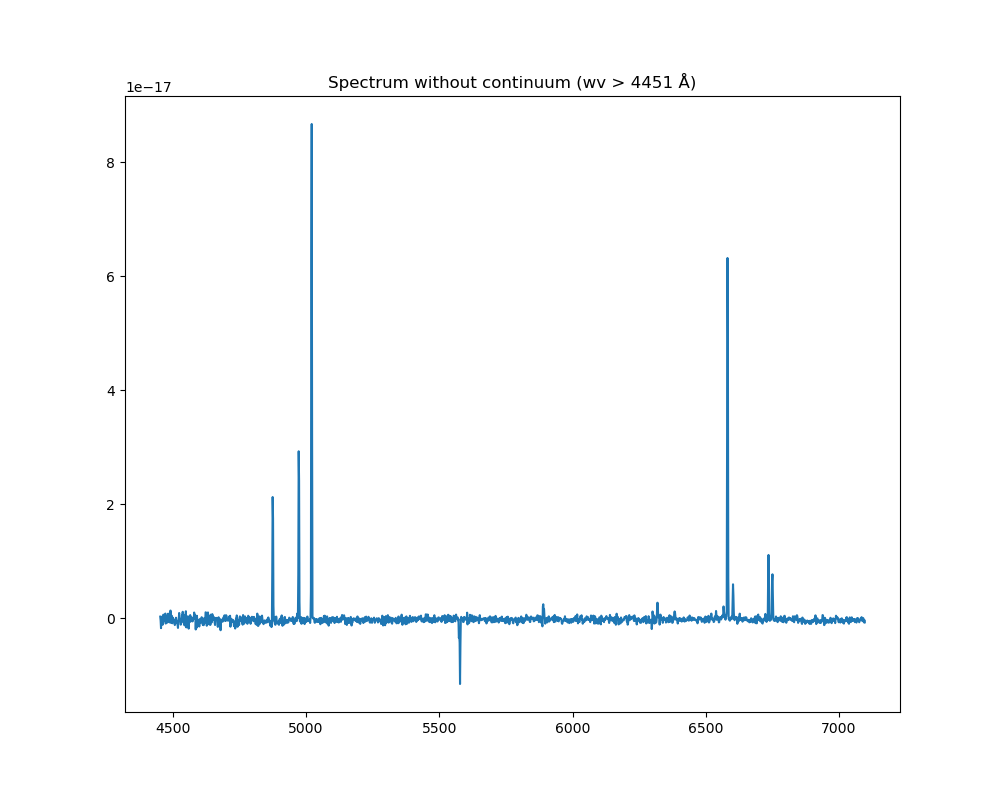

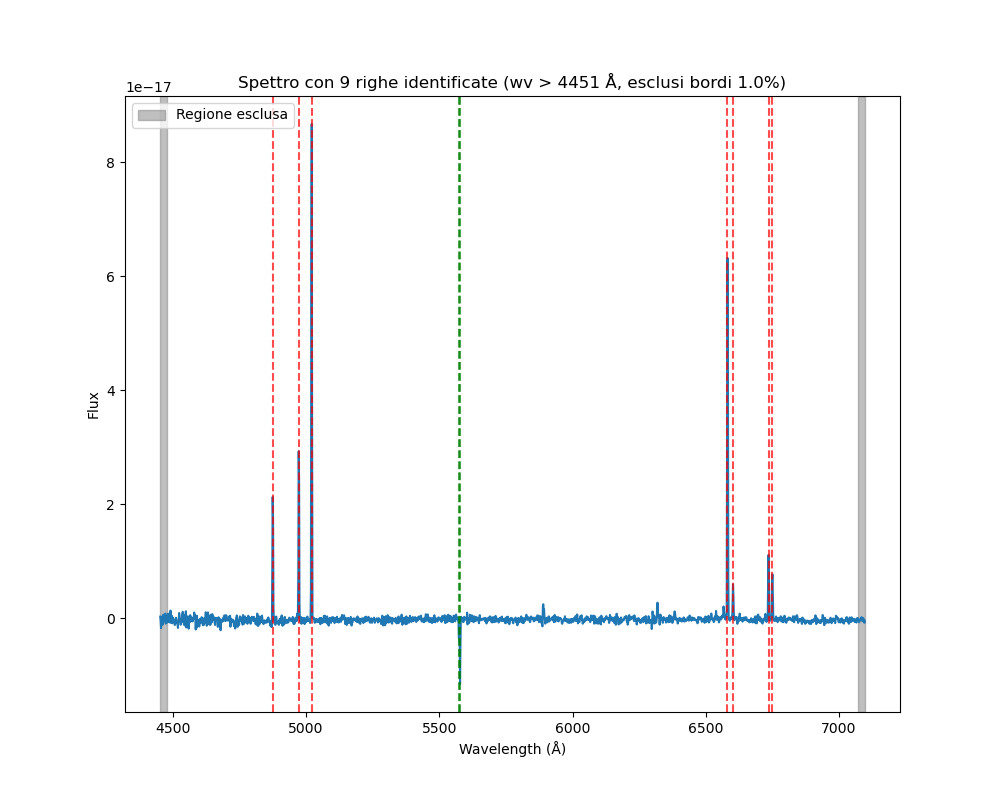

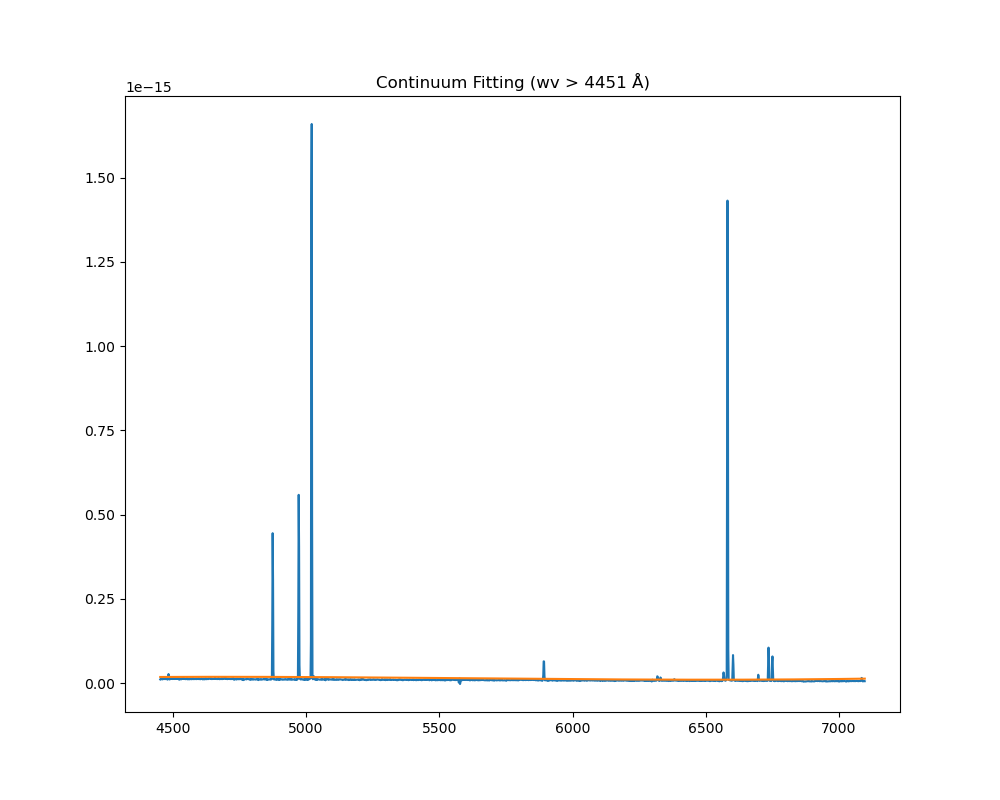

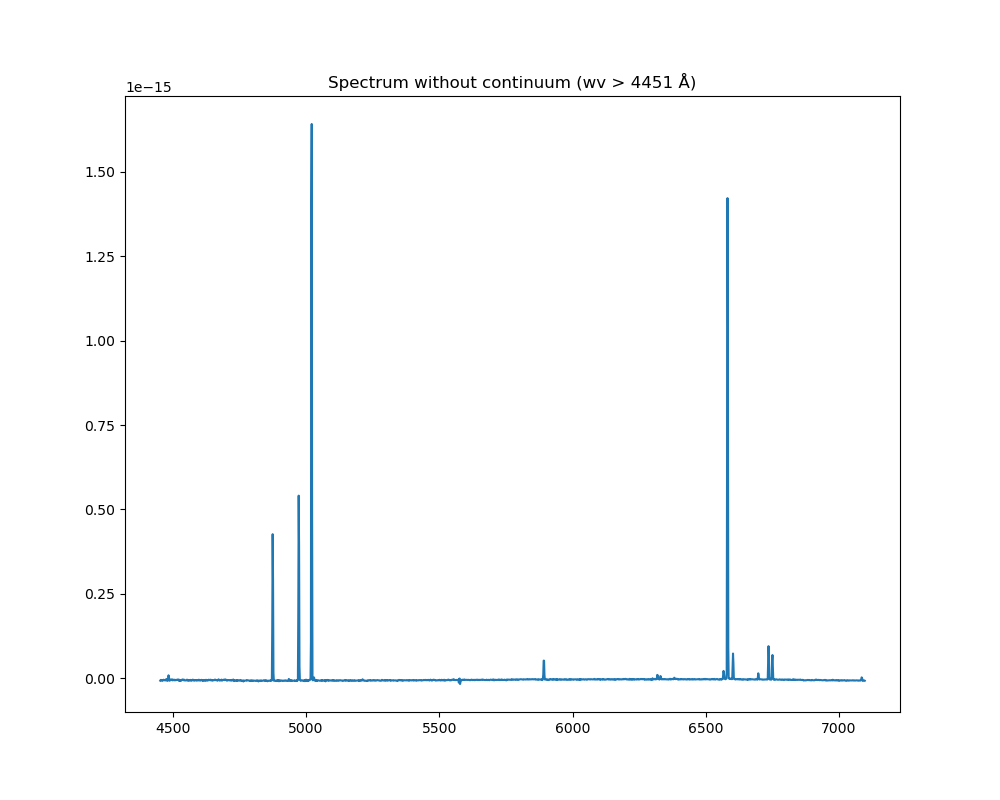

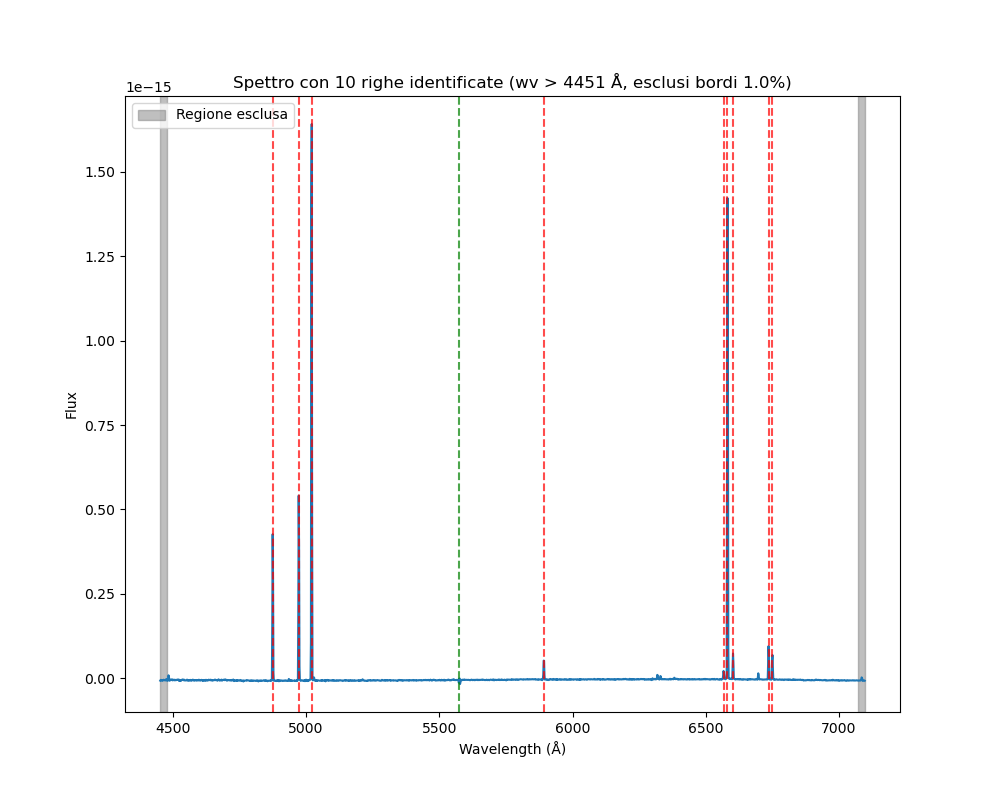

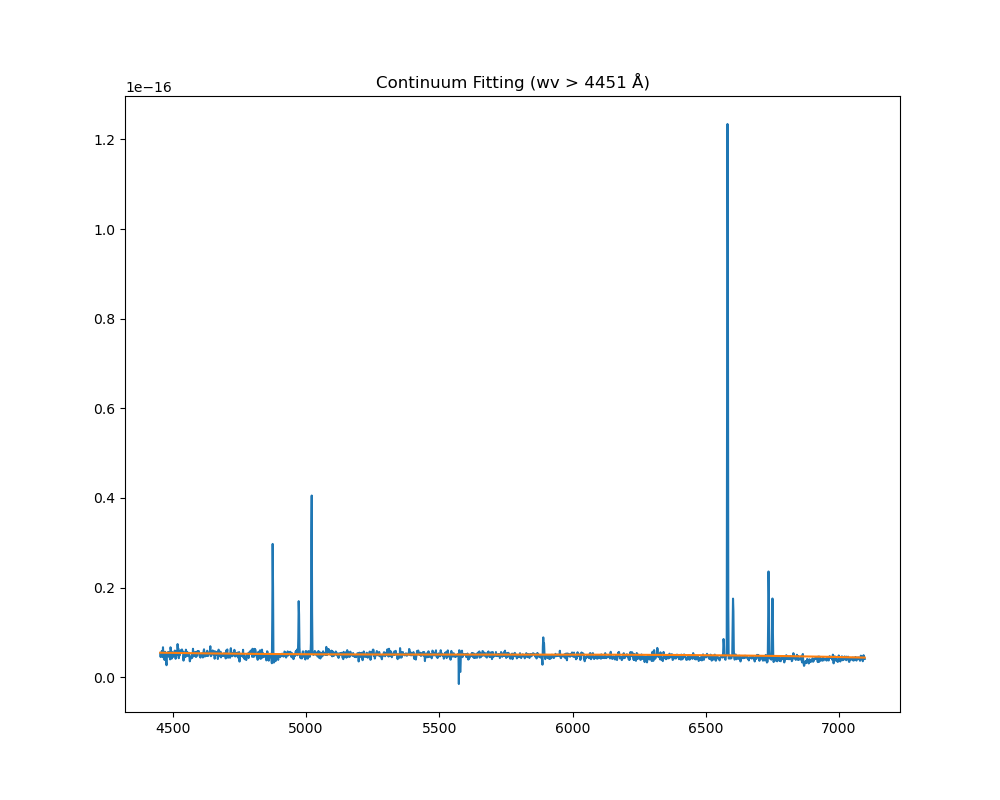

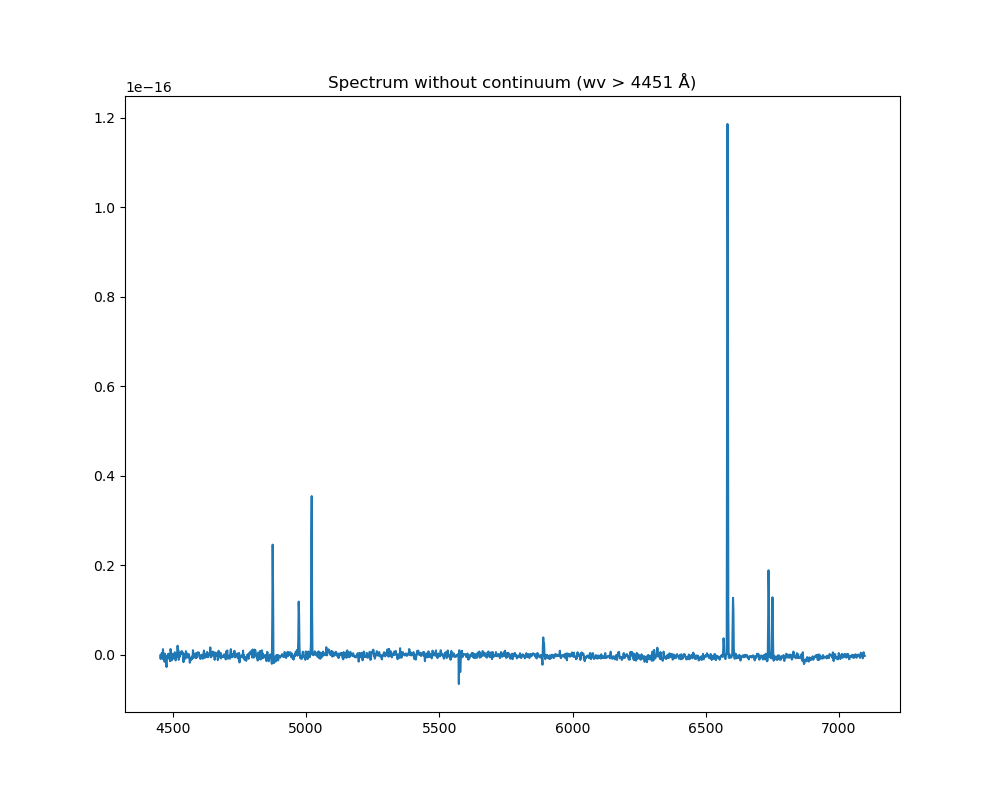

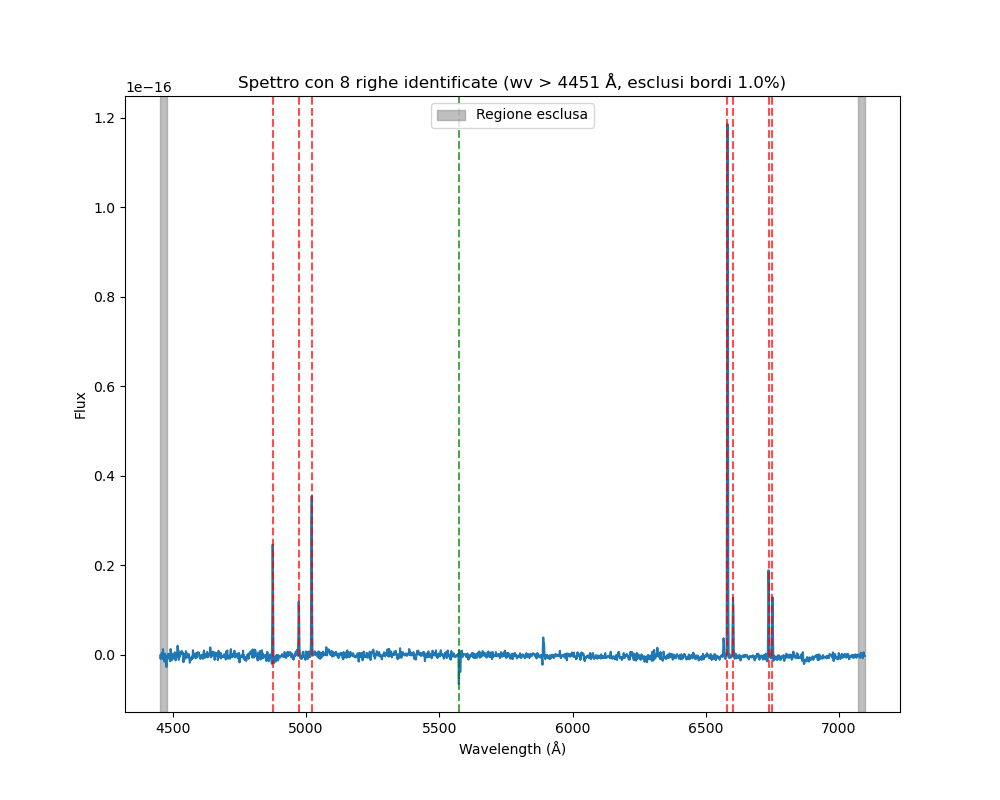

In [46]:
all_lines = []
noise_factor = [10, 8, 18, 8]

# Filtra per lunghezze d'ondaù > 4451 Å
wv_mask = wv > 4452
wv_filtered = wv[wv_mask]

# Definisci la percentuale di spettro da escludere ai bordi (es. 5% per lato)
edge_fraction = 0.01
n_points = len(wv_filtered)
start_idx = int(n_points * edge_fraction)
end_idx = int(n_points * (1 - edge_fraction))

# Crea gli array ritagliati per la regione centrale (già filtrata per wv > 4451)
wv_central = wv_filtered[start_idx:end_idx]

for i in range(len(peaks)):
    # Applica il filtro anche agli spettri
    spectra_filtered = spectra_1[i][wv_mask]
    spectra_err_filtered = spectra_err_1[i][wv_mask]
    
    # Usa lo spettro filtrato per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux = spectra_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv_filtered * u.Angstrom)
    
    f, ax = plt.subplots(figsize = (10,8))
    ax.plot(wv_filtered * u.Angstrom, spectra_filtered * 1e-16*u.erg / (u.cm**2 * u.s * u.Angstrom))
    ax.plot(wv_filtered * u.Angstrom, y_continuum_fitted)
    ax.set_title("Continuum Fitting (wv > 4451 Å)")
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    f2, ax2 = plt.subplots(figsize = (10,8))
    ax2.plot(wv_filtered * u.Angstrom, flux_continuum_subtracted)
    ax2.set_title("Spectrum without continuum (wv > 4451 Å)")
    
    # Crea lo spettro solo per la regione centrale (senza bordi, già filtrata per wv > 4451)
    spectrum_no_continuum_central = Spectrum(
        spectral_axis=wv_central * u.Angstrom,
        flux=flux_continuum_subtracted[start_idx:end_idx],
        uncertainty=StdDevUncertainty(spectra_err_filtered[start_idx:end_idx] * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe solo nella regione centrale
    lines = find_lines_threshold(spectrum_no_continuum_central, noise_factor = noise_factor[i])
    print(f"Numero di righe trovate (regione centrale, wv > 4451 Å): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv_filtered, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line in lines:
            line_center = line['line_center'].value
            line_type = line['line_type']
            
            if line_type == 'emission':
                ax3.axvline(x=line_center, color='red', alpha=0.7, linestyle='--')
            else:  # absorption
                ax3.axvline(x=line_center, color='green', alpha=0.7, linestyle='--')
                
    # Aggiungi linee verticali per indicare i bordi esclusi
    ax3.axvspan(wv_filtered[0], wv_filtered[start_idx], alpha=0.5, color='gray', zorder=1, label='Regione esclusa')
    ax3.axvspan(wv_filtered[end_idx-1], wv_filtered[-1], alpha=0.5, color='gray', zorder=1)
    ax3.legend()
    
    ax3.set_title(f"Spettro con {len(lines)} righe identificate (wv > 4451 Å, esclusi bordi {edge_fraction*100:.1f}%)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [47]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6

lines_1 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_HA, l_NII_2, l_SII_1, l_SII_2] 
lines_2 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2] # per 2, 4
lines_3 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2] 
lines_spectrum_1 = all_lines[0]['line_center'] 
lines_spectrum_2 = all_lines[1]['line_center']
lines_spectrum_3 = all_lines[2]['line_center']
lines_spectrum_4 = all_lines[3]['line_center']
#lines_spectrum_5 = all_lines[4]['line_center']

z_1 = np.zeros(8)
z_2 = np.zeros(7)
z_3 = np.zeros(9)
z_4 = np.zeros(7)

for i in range(8):
    z_1[i] = lines_spectrum_1[i].value / lines_1[i] - 1
    
for i in range(7):
    z_2[i] = lines_spectrum_2[i].value / lines_2[i] - 1
    z_4[i] = lines_spectrum_4[i].value / lines_2[i] - 1
    
for i in range(9):
    z_3[i] = lines_spectrum_3[i].value / lines_3[i] - 1
    
z_1_mean = np.mean(z_1)
z_2_mean = np.mean(z_2)
z_3_mean = np.mean(z_3)
z_4_mean = np.mean(z_4)

z_1_std = np.std(z_1)
z_2_std = np.std(z_2)
z_3_std = np.std(z_3) 
z_4_std = np.std(z_4)

print(z_1_mean)
print(z_1_std)
print(z_2_mean)
print(z_2_std)
print(z_3_mean)
print(z_3_std)
print(z_4_mean)
print(z_4_std)

z = [z_1_mean, z_2_mean, z_3_mean, z_4_mean]
z_err = [z_1_std, z_2_std, z_3_std, z_4_std]

0.006431511703733128
0.009556124541984796
0.002819697959896006
5.977692559156352e-05
0.002812571173447859
5.765955666975587e-05
0.002819697959896006
5.977692559156352e-05


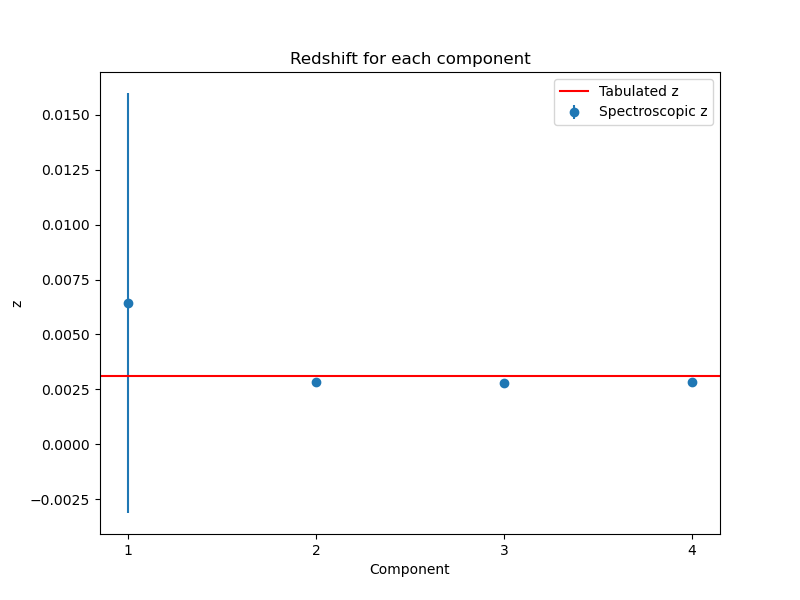

In [48]:
plt.figure(figsize=(8, 6))
comp = [1, 2, 3, 4]
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
plt.axhline(0.00309, color = 'red', label = 'Tabulated z')
plt.title('Redshift for each component')
plt.legend()
plt.savefig('Redshift', bbox_inches='tight')

red_table = np.column_stack((z, z_err))
np.savetxt('redshift.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

In [43]:
z_1

array([0.00281406, 0.00277481, 0.00293601, 0.03171421, 0.0028372 ,
       0.00284655, 0.00273039, 0.00279887])